In [1]:
'''Download the Zomato Restaurants Kaggle dataset, load it into a pandas DataFrame, and display the first 5 rows along with info() and describe() output.
'''
import pandas as pd

df = pd.read_csv("zomato.csv")

print(df.head())

df.info()

print(df.describe())

   Unnamed: 0.1  Unnamed: 0     restaurant name restaurant type  \
0             0           0        #FeelTheROLL     Quick Bites   
1             1           1          #L-81 Cafe     Quick Bites   
2             2           2             #refuel            Cafe   
3             3           3  '@ Biryani Central   Casual Dining   
4             4           4          '@ The Bbq   Casual Dining   

   rate (out of 5)  num of ratings  avg cost (two people) online_order  \
0              3.4               7                  200.0           No   
1              3.9              48                  400.0          Yes   
2              3.7              37                  400.0          Yes   
3              2.7             135                  550.0          Yes   
4              2.8              40                  700.0          Yes   

  table booking                                      cuisines type  \
0            No                                          Fast Food   
1           

Missing values BEFORE handling:
rate (out of 5)          68
avg cost (two people)    57
dtype: int64

Number of Rating outliers: 39
Number of Cost outliers: 661

Rating limits:
Lower: 2.3000000000000007
Upper: 4.699999999999999

Cost limits:
Lower: -150.0
Upper: 1050.0

Missing values AFTER handling:
rate (out of 5)          0
avg cost (two people)    0
dtype: int64


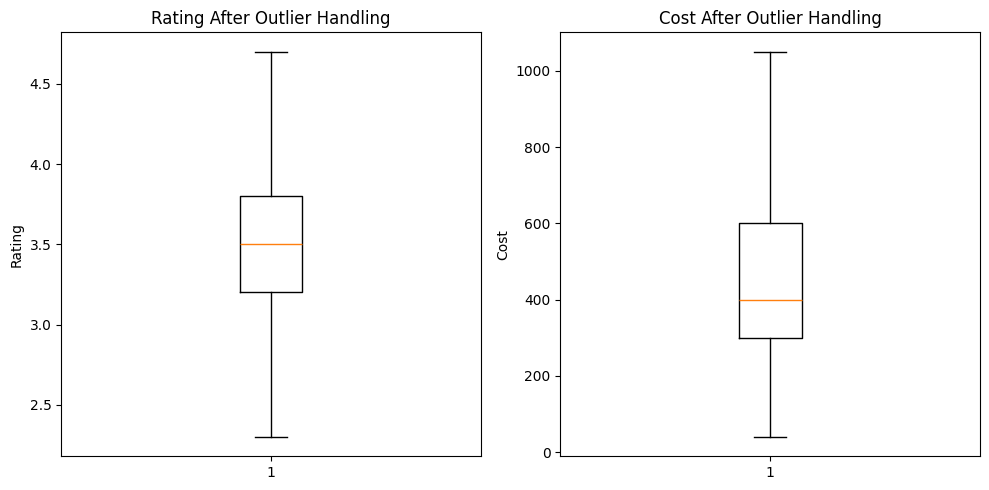


Final statistics:
       rate (out of 5)  avg cost (two people)
count      7105.000000            7105.000000
mean          3.514314             480.561436
std           0.459649             272.678474
min           2.300000              40.000000
25%           3.200000             300.000000
50%           3.500000             400.000000
75%           3.800000             600.000000
max           4.700000            1050.000000


In [6]:
'''Check the Zomato dataset for missing values and outliers in the 'cost' and 'rating' columns, and handle them appropriately using pandas and numpy.<br><br><em><strong>Hint:</strong> For outliers, try using the IQR method or visualize with a boxplot.</em>'''


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("zomato.csv")

# -----------------------------------
# 1. Clean Rating column
# -----------------------------------

df["rate (out of 5)"] = (
    df["rate (out of 5)"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
)

df["rate (out of 5)"] = pd.to_numeric(
    df["rate (out of 5)"],
    errors="coerce"
)

# -----------------------------------
# 2. Clean Cost column
# -----------------------------------

df["avg cost (two people)"] = (
    df["avg cost (two people)"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["avg cost (two people)"] = pd.to_numeric(
    df["avg cost (two people)"],
    errors="coerce"
)

# -----------------------------------
# 3. Check missing values
# -----------------------------------

print("Missing values BEFORE handling:")
print(df[["rate (out of 5)", "avg cost (two people)"]].isnull().sum())

# -----------------------------------
# 4. Handle missing values
#    Using median
# -----------------------------------

df["rate (out of 5)"] = df["rate (out of 5)"].fillna(
    df["rate (out of 5)"].median()
)

df["avg cost (two people)"] = df["avg cost (two people)"].fillna(
    df["avg cost (two people)"].median()
)

# -----------------------------------
# 5. Detect Rating outliers using IQR
# -----------------------------------

Q1_rating = df["rate (out of 5)"].quantile(0.25)
Q3_rating = df["rate (out of 5)"].quantile(0.75)

IQR_rating = Q3_rating - Q1_rating

lower_rating = Q1_rating - 1.5 * IQR_rating
upper_rating = Q3_rating + 1.5 * IQR_rating

rating_outliers = df[
    (df["rate (out of 5)"] < lower_rating) |
    (df["rate (out of 5)"] > upper_rating)
]

# -----------------------------------
# 6. Detect Cost outliers using IQR
# -----------------------------------

Q1_cost = df["avg cost (two people)"].quantile(0.25)
Q3_cost = df["avg cost (two people)"].quantile(0.75)

IQR_cost = Q3_cost - Q1_cost

lower_cost = Q1_cost - 1.5 * IQR_cost
upper_cost = Q3_cost + 1.5 * IQR_cost

cost_outliers = df[
    (df["avg cost (two people)"] < lower_cost) |
    (df["avg cost (two people)"] > upper_cost)
]

# -----------------------------------
# 7. Print outlier information
# -----------------------------------

print("\nNumber of Rating outliers:", len(rating_outliers))
print("Number of Cost outliers:", len(cost_outliers))

print("\nRating limits:")
print("Lower:", lower_rating)
print("Upper:", upper_rating)

print("\nCost limits:")
print("Lower:", lower_cost)
print("Upper:", upper_cost)

# -----------------------------------
# 8. Handle outliers using clipping
# -----------------------------------

df["rate (out of 5)"] = df["rate (out of 5)"].clip(
    lower=lower_rating,
    upper=upper_rating
)

df["avg cost (two people)"] = df["avg cost (two people)"].clip(
    lower=lower_cost,
    upper=upper_cost
)

# -----------------------------------
# 9. Check missing values AFTER handling
# -----------------------------------

print("\nMissing values AFTER handling:")
print(df[["rate (out of 5)", "avg cost (two people)"]].isnull().sum())

# -----------------------------------
# 10. Boxplots
# -----------------------------------

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.boxplot(df["rate (out of 5)"])
plt.title("Rating After Outlier Handling")
plt.ylabel("Rating")

plt.subplot(1, 2, 2)
plt.boxplot(df["avg cost (two people)"])
plt.title("Cost After Outlier Handling")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

# -----------------------------------
# 11. Final statistics
# -----------------------------------

print("\nFinal statistics:")
print(df[["rate (out of 5)", "avg cost (two people)"]].describe())

In [7]:
'''Encode the 'cuisine' and 'location' categorical columns using OneHotEncoder or LabelEncoder, and scale the 'cost' and 'rating' columns using StandardScaler.'''

import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Load dataset
df = pd.read_csv("zomato.csv")

# -----------------------------------
# 1. Clean Rating
# -----------------------------------

df["rate (out of 5)"] = (
    df["rate (out of 5)"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
)

df["rate (out of 5)"] = pd.to_numeric(
    df["rate (out of 5)"],
    errors="coerce"
)

# -----------------------------------
# 2. Clean Cost
# -----------------------------------

df["avg cost (two people)"] = (
    df["avg cost (two people)"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["avg cost (two people)"] = pd.to_numeric(
    df["avg cost (two people)"],
    errors="coerce"
)

# -----------------------------------
# 3. Handle missing values
# -----------------------------------

df["rate (out of 5)"] = df["rate (out of 5)"].fillna(
    df["rate (out of 5)"].median()
)

df["avg cost (two people)"] = df["avg cost (two people)"].fillna(
    df["avg cost (two people)"].median()
)

# -----------------------------------
# 4. Encode categorical columns
# -----------------------------------

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded = encoder.fit_transform(
    df[["cuisines type", "area"]]
)

encoded_columns = encoder.get_feature_names_out(
    ["cuisines type", "area"]
)

encoded_df = pd.DataFrame(
    encoded,
    columns=encoded_columns,
    index=df.index
)

# Add encoded columns to dataframe
df = pd.concat(
    [df, encoded_df],
    axis=1
)

# -----------------------------------
# 5. Scale cost and rating
# -----------------------------------

scaler = StandardScaler()

df[["avg cost (two people)", "rate (out of 5)"]] = scaler.fit_transform(
    df[["avg cost (two people)", "rate (out of 5)"]]
)

# -----------------------------------
# 6. Display result
# -----------------------------------

print("Encoded + Scaled Data:")
print(df.head())

print("\nEncoded columns:")
print(encoded_columns)

print("\nScaled columns:")
print(df[["avg cost (two people)", "rate (out of 5)"]].head())

Encoded + Scaled Data:
   Unnamed: 0.1  Unnamed: 0     restaurant name restaurant type  \
0             0           0        #FeelTheROLL     Quick Bites   
1             1           1          #L-81 Cafe     Quick Bites   
2             2           2             #refuel            Cafe   
3             3           3  '@ Biryani Central   Casual Dining   
4             4           4          '@ The Bbq   Casual Dining   

   rate (out of 5)  num of ratings  avg cost (two people) online_order  \
0        -0.247544               7              -0.735422           No   
1         0.837064              48              -0.301751          Yes   
2         0.403221              37              -0.301751          Yes   
3        -1.765996             135               0.023503          Yes   
4        -1.549075              40               0.348756          Yes   

  table booking                                      cuisines type  ...  \
0            No                                       

In [9]:
'''Split the Zomato data into train and test sets (80/20), then train both a Logistic Regression and a Random Forest model to predict whether a restaurant has a rating above 4.0. Compare their ROC-AUC scores and print which model performed better.'''

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score


# -----------------------------------
# 1. Load dataset
# -----------------------------------

df = pd.read_csv("zomato.csv")


# -----------------------------------
# 2. Clean Rating
# -----------------------------------

df["rate (out of 5)"] = (
    df["rate (out of 5)"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0]
)

df["rate (out of 5)"] = pd.to_numeric(
    df["rate (out of 5)"],
    errors="coerce"
)


# -----------------------------------
# 3. Clean Cost
# -----------------------------------

df["avg cost (two people)"] = (
    df["avg cost (two people)"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["avg cost (two people)"] = pd.to_numeric(
    df["avg cost (two people)"],
    errors="coerce"
)


# -----------------------------------
# 4. Remove rows where rating is missing
#    because rating is needed to create target
# -----------------------------------

df = df.dropna(subset=["rate (out of 5)"])


# -----------------------------------
# 5. Create Target
# -----------------------------------

df["high_rating"] = (
    df["rate (out of 5)"] > 4.0
).astype(int)


# -----------------------------------
# 6. Features and Target
# -----------------------------------

X = df[
    [
        "cuisines type",
        "area",
        "avg cost (two people)"
    ]
]

y = df["high_rating"]


# -----------------------------------
# 7. Train-Test Split
# -----------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# -----------------------------------
# 8. Preprocessing
# -----------------------------------

categorical_features = [
    "cuisines type",
    "area"
]

numeric_features = [
    "avg cost (two people)"
]


preprocessor = ColumnTransformer(
    transformers=[
        
        # Categorical columns
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        ),
        
        # Numerical column
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        )
    ]
)


# -----------------------------------
# 9. Logistic Regression
# -----------------------------------

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_prob = logistic_model.predict_proba(
    X_test
)[:, 1]

logistic_auc = roc_auc_score(
    y_test,
    logistic_prob
)


# -----------------------------------
# 10. Random Forest
# -----------------------------------

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

random_forest_prob = random_forest_model.predict_proba(
    X_test
)[:, 1]

random_forest_auc = roc_auc_score(
    y_test,
    random_forest_prob
)


# -----------------------------------
# 11. Compare ROC-AUC
# -----------------------------------

print("Logistic Regression ROC-AUC:",
      logistic_auc)

print("Random Forest ROC-AUC:",
      random_forest_auc)


if logistic_auc > random_forest_auc:
    print("\nLogistic Regression performed better.")

elif random_forest_auc > logistic_auc:
    print("\nRandom Forest performed better.")

else:
    print("\nBoth models performed equally.")

Logistic Regression ROC-AUC: 0.8493777827455802
Random Forest ROC-AUC: 0.7722456640399412

Logistic Regression performed better.
